# Exploratory Data Analysis (EDA) of Insurance Policy PDF Documents

## Introduction

This notebook performs a comprehensive exploratory data analysis on insurance policy PDF documents located in the `data/queplan_insurance/` directory. The analysis involves:

1. **Data Source**: PDF files containing insurance policy documents
2. **Objective**: Extract, clean, and analyze the content to understand the structure and characteristics of insurance policies
3. **Scope**: Complete text extraction, data cleaning, statistical analysis, and visualization of key insurance policy features

The PDFs contain structured insurance policy information written in Spanish, including policy numbers, coverage types, articles, and detailed terms and conditions.

## 1. Library Imports and Setup

First, we'll import all necessary libraries for PDF parsing, data manipulation, and visualization.

In [1]:
import os
import re
import warnings
from pathlib import Path
from collections import Counter
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import fitz
except ImportError:
    print("Installing PyMuPDF for PDF extraction...")
    !pip install PyMuPDF
    import fitz

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis Date: 2025-10-03 16:59:41


## 2. Data Loading and PDF Text Extraction

We'll define functions to extract text from PDFs and process all files in the target directory.

In [2]:
PDF_FOLDER = 'data/queplan_insurance/'

def extract_text_from_pdf(pdf_path):
    """
    Extract all text content from a PDF file using PyMuPDF.
    
    Args:
        pdf_path (str): Path to the PDF file
        
    Returns:
        str: Extracted text content
    """
    try:
        doc = fitz.open(pdf_path)
        text = ""
        for page_num in range(len(doc)):
            page = doc[page_num]
            text += page.get_text()
        doc.close()
        return text.strip()
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
        return ""

def extract_policy_number(text, filename):
    """
    Extract policy number from text or filename.
    
    Args:
        text (str): PDF text content
        filename (str): PDF filename
        
    Returns:
        str: Policy number
    """
    patterns = [
        r'(?:POL|PÓLIZA)\s*[N°]?\s*(\d+)',
        r'Policy\s*(?:Number|No\.?)\s*:?\s*(\d+)',
        r'Número\s*de\s*(?:Póliza|Poliza)\s*:?\s*(\d+)'
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group(1)
    
    match = re.search(r'POL(\d+)', filename)
    if match:
        return match.group(1)
    
    return "Unknown"

def extract_policy_type(text):
    """
    Extract policy type from text.
    
    Args:
        text (str): PDF text content
        
    Returns:
        str: Policy type
    """
    keywords = {
        'Catastrófico': r'(?i)catastrófico|catastrofico',
        'Hospitalización': r'(?i)hospitalización|hospitalizacion',
        'Salud': r'(?i)salud|health',
        'Accidente': r'(?i)accidente|accident',
        'Vida': r'(?i)vida|life',
        'Dental': r'(?i)dental',
        'Complementario': r'(?i)complementario|complementary'
    }
    
    detected_types = []
    for policy_type, pattern in keywords.items():
        if re.search(pattern, text):
            detected_types.append(policy_type)
    
    return ', '.join(detected_types) if detected_types else "General"

def count_articles(text):
    """
    Count the number of articles in the policy document.
    
    Args:
        text (str): PDF text content
        
    Returns:
        int: Number of articles
    """
    pattern = r'ARTÍCULO\s*\d+°?|ARTICULO\s*\d+°?'
    matches = re.findall(pattern, text, re.IGNORECASE)
    return len(matches)

def extract_coverage_info(text):
    """
    Extract coverage-related keywords and information.
    
    Args:
        text (str): PDF text content
        
    Returns:
        dict: Coverage information
    """
    coverage_keywords = [
        'cobertura', 'reembolso', 'deducible', 'prima',
        'exclusión', 'beneficio', 'asegurado', 'prestación'
    ]
    
    coverage_counts = {}
    for keyword in coverage_keywords:
        count = len(re.findall(r'\b' + keyword + r'\b', text, re.IGNORECASE))
        coverage_counts[keyword] = count
    
    return coverage_counts

print("PDF extraction functions defined successfully!")

PDF extraction functions defined successfully!


In [3]:
if not os.path.exists(PDF_FOLDER):
    print(f"Error: The folder '{PDF_FOLDER}' was not found.")
    print("Please ensure the PDF files are in the correct location.")
else:
    pdf_files = [f for f in os.listdir(PDF_FOLDER) if f.endswith('.pdf')]
    print(f"Found {len(pdf_files)} PDF files in '{PDF_FOLDER}'")
    print("\nFiles:")
    for i, file in enumerate(pdf_files, 1):
        file_path = os.path.join(PDF_FOLDER, file)
        size_kb = os.path.getsize(file_path) / 1024
        print(f"  {i}. {file} ({size_kb:.1f} KB)")

Found 9 PDF files in 'data/queplan_insurance/'

Files:
  1. POL320180100.pdf (39.2 KB)
  2. POL320190074.pdf (89.1 KB)
  3. POL320200214.pdf (245.7 KB)
  4. POL320210210.pdf (17.3 KB)
  5. POL320150503.pdf (41.5 KB)
  6. POL320130223.pdf (47.8 KB)
  7. POL320210063.pdf (13.6 KB)
  8. POL120190177.pdf (33.3 KB)
  9. POL320200071.pdf (53.0 KB)


In [4]:
data_records = []

print("Extracting data from PDF files...\n")

for filename in pdf_files:
    pdf_path = os.path.join(PDF_FOLDER, filename)
    print(f"Processing: {filename}")
    
    text_content = extract_text_from_pdf(pdf_path)
    
    if text_content:
        policy_num = extract_policy_number(text_content, filename)
        policy_type = extract_policy_type(text_content)
        article_count = count_articles(text_content)
        coverage_info = extract_coverage_info(text_content)
        
        record = {
            'filename': filename,
            'policy_number': policy_num,
            'policy_type': policy_type,
            'text_length': len(text_content),
            'word_count': len(text_content.split()),
            'article_count': article_count,
            'page_count': fitz.open(pdf_path).page_count,
            'full_text': text_content,
        }
        
        record.update(coverage_info)
        data_records.append(record)
        
        print(f"  ✓ Policy: {policy_num}, Type: {policy_type}, Articles: {article_count}\n")
    else:
        print(f"  ✗ Failed to extract text\n")

df_policies = pd.DataFrame(data_records)
print(f"\n{'='*60}")
print(f"Extraction completed! Total policies processed: {len(df_policies)}")
print(f"{'='*60}")

Extracting data from PDF files...

Processing: POL320180100.pdf
  ✓ Policy: 320180100, Type: Hospitalización, Salud, Accidente, Vida, Dental, Complementario, Articles: 45

Processing: POL320190074.pdf
  ✓ Policy: 320190074, Type: Hospitalización, Salud, Accidente, Vida, Dental, Complementario, Articles: 39

Processing: POL320200214.pdf
  ✓ Policy: 320200214, Type: Hospitalización, Salud, Accidente, Vida, Complementario, Articles: 26

Processing: POL320210210.pdf
  ✓ Policy: 320210210, Type: Hospitalización, Salud, Accidente, Vida, Dental, Articles: 21

Processing: POL320150503.pdf
  ✓ Policy: 320150503, Type: Hospitalización, Salud, Accidente, Vida, Dental, Complementario, Articles: 46

Processing: POL320130223.pdf
  ✓ Policy: 320130223, Type: Hospitalización, Salud, Accidente, Vida, Dental, Complementario, Articles: 9

Processing: POL320210063.pdf
  ✓ Policy: 320210063, Type: Hospitalización, Salud, Accidente, Vida, Articles: 30

Processing: POL120190177.pdf
  ✓ Policy: 120190177, Typ

In [5]:
print("Dataset Overview:")
print(f"Shape: {df_policies.shape}")
print(f"\nColumns: {df_policies.columns.tolist()}")
print("\nFirst few rows:")
df_policies.drop('full_text', axis=1).head()

Dataset Overview:
Shape: (9, 16)

Columns: ['filename', 'policy_number', 'policy_type', 'text_length', 'word_count', 'article_count', 'page_count', 'full_text', 'cobertura', 'reembolso', 'deducible', 'prima', 'exclusión', 'beneficio', 'asegurado', 'prestación']

First few rows:


,filename,policy_number,policy_type,text_length,word_count,article_count,page_count,cobertura,reembolso,deducible,prima,exclusión,beneficio,asegurado,prestación
0,POL320180100.pdf,320180100,"Hospitalización, Salud, Accidente, Vida, Denta...",58479,8957,45,25,23,37,14,24,1,1,139,3
1,POL320190074.pdf,320190074,"Hospitalización, Salud, Accidente, Vida, Denta...",106447,15813,39,72,74,45,11,11,0,45,222,10
2,POL320200214.pdf,320200214,"Hospitalización, Salud, Accidente, Vida, Compl...",79457,11903,26,42,45,25,25,26,4,18,177,7
3,POL320210210.pdf,320210210,"Hospitalización, Salud, Accidente, Vida, Dental",25682,3816,21,10,12,10,3,5,0,6,53,1
4,POL320150503.pdf,320150503,"Hospitalización, Salud, Accidente, Vida, Denta...",63177,9603,46,26,23,34,13,25,0,1,139,4


## 3. Data Cleaning and Preprocessing

We'll clean and standardize the extracted data for better analysis.

In [6]:
df_clean = df_policies.copy()

print("Data Quality Check:")
print("\nMissing Values:")
missing_summary = df_clean.isnull().sum()
print(missing_summary[missing_summary > 0] if any(missing_summary > 0) else "No missing values")

print("\nData Types:")
print(df_clean.dtypes)

df_clean['policy_number'] = df_clean['policy_number'].fillna('Unknown')
df_clean['policy_type'] = df_clean['policy_type'].fillna('General')

df_clean['avg_words_per_page'] = df_clean['word_count'] / df_clean['page_count']
df_clean['avg_chars_per_word'] = df_clean['text_length'] / df_clean['word_count']

print("\n✓ Data cleaning completed!")
print(f"Final dataset shape: {df_clean.shape}")

Data Quality Check:

Missing Values:
No missing values

Data Types:
filename         object
policy_number    object
policy_type      object
text_length       int64
word_count        int64
article_count     int64
page_count        int64
full_text        object
cobertura         int64
reembolso         int64
deducible         int64
prima             int64
exclusión         int64
beneficio         int64
asegurado         int64
prestación        int64
dtype: object

✓ Data cleaning completed!
Final dataset shape: (9, 18)


## 4. Univariate Analysis

We'll analyze individual features to understand their distributions and characteristics.

In [7]:
print("Descriptive Statistics for Numerical Features:\n")
numeric_cols = ['text_length', 'word_count', 'article_count', 'page_count', 
                'avg_words_per_page', 'avg_chars_per_word']
df_clean[numeric_cols].describe().T

Descriptive Statistics for Numerical Features:



,count,mean,std,min,25%,50%,75%,max
text_length,9.0,60868.555556,28117.840178,16380.000000,53226.000000,59344.000000,79457.000000,106447.000000
word_count,9.0,9202.555556,4210.201483,2555.000000,7877.000000,9143.000000,11903.000000,15813.000000
article_count,9.0,37.444444,18.980985,9.000000,26.000000,39.000000,46.000000,75.000000
page_count,9.0,29.666667,20.898565,6.000000,14.000000,25.000000,42.000000,72.000000
avg_words_per_page,9.0,376.110714,149.446006,167.595745,283.404762,369.346154,425.833333,653.071429
avg_chars_per_word,9.0,6.601333,0.125592,6.410959,6.508437,6.578882,6.730084,6.757141


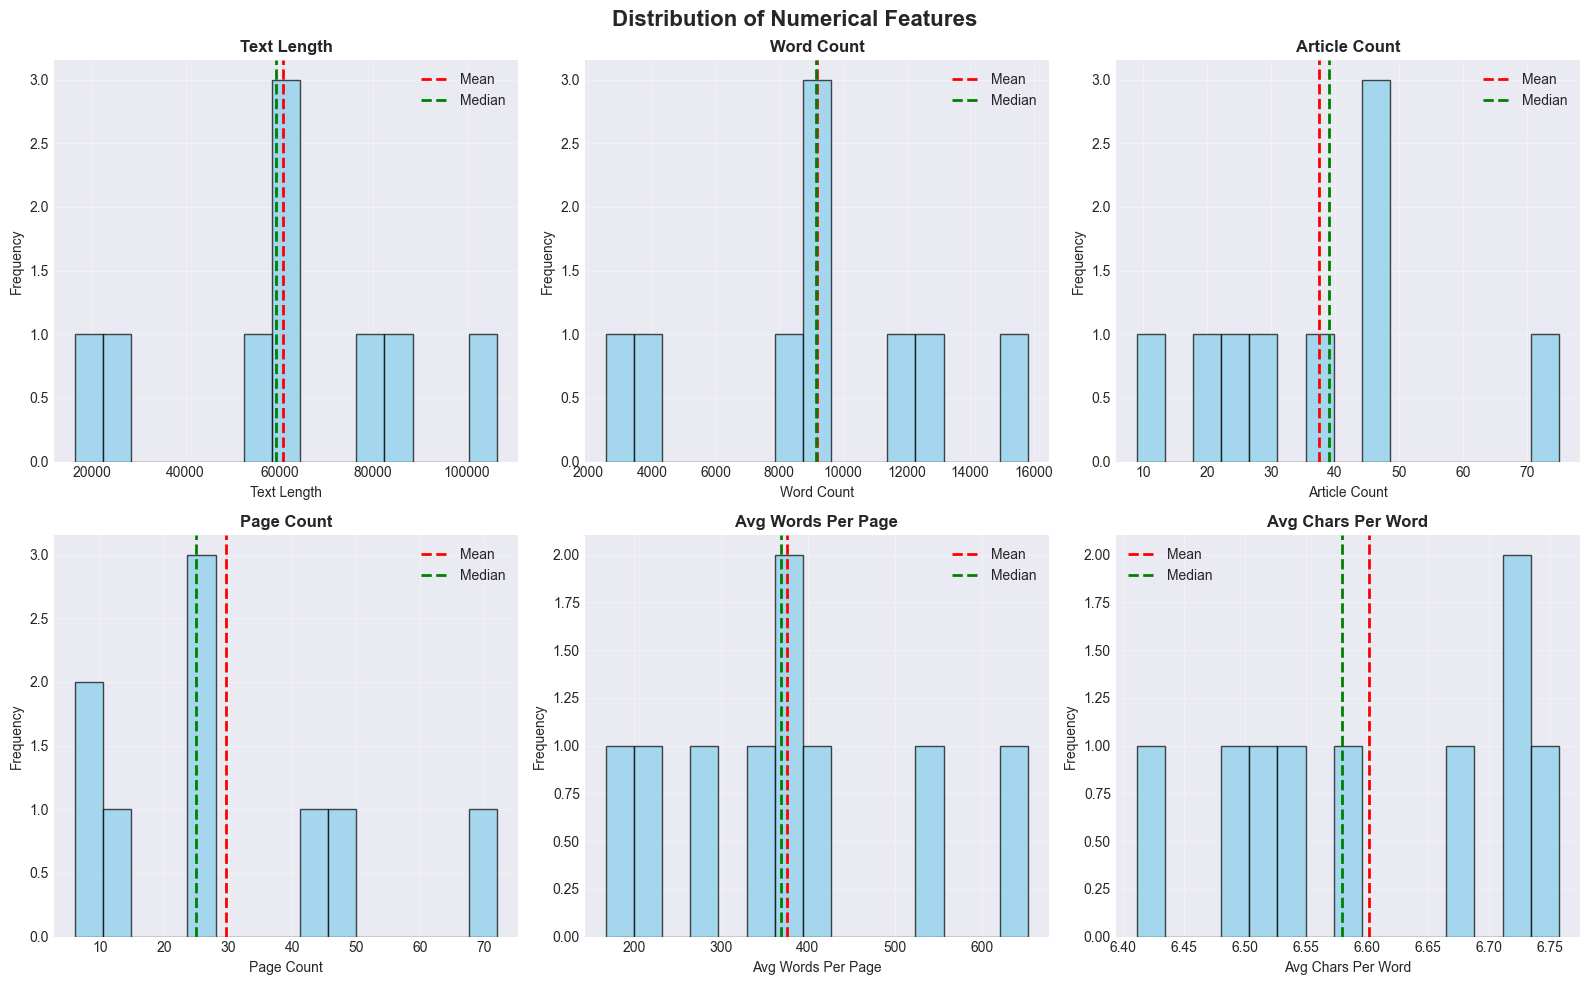

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3, idx % 3]
    
    df_clean[col].hist(bins=15, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(df_clean[col].median(), color='green', linestyle='--', linewidth=2, label='Median')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Policy Type Distribution:

policy_type
Hospitalización, Salud, Accidente, Vida, Dental, Complementario    5
Hospitalización, Salud, Accidente, Vida, Complementario            1
Hospitalización, Salud, Accidente, Vida, Dental                    1
Hospitalización, Salud, Accidente, Vida                            1
Catastrófico, Hospitalización, Salud, Accidente, Vida, Dental      1
Name: count, dtype: int64


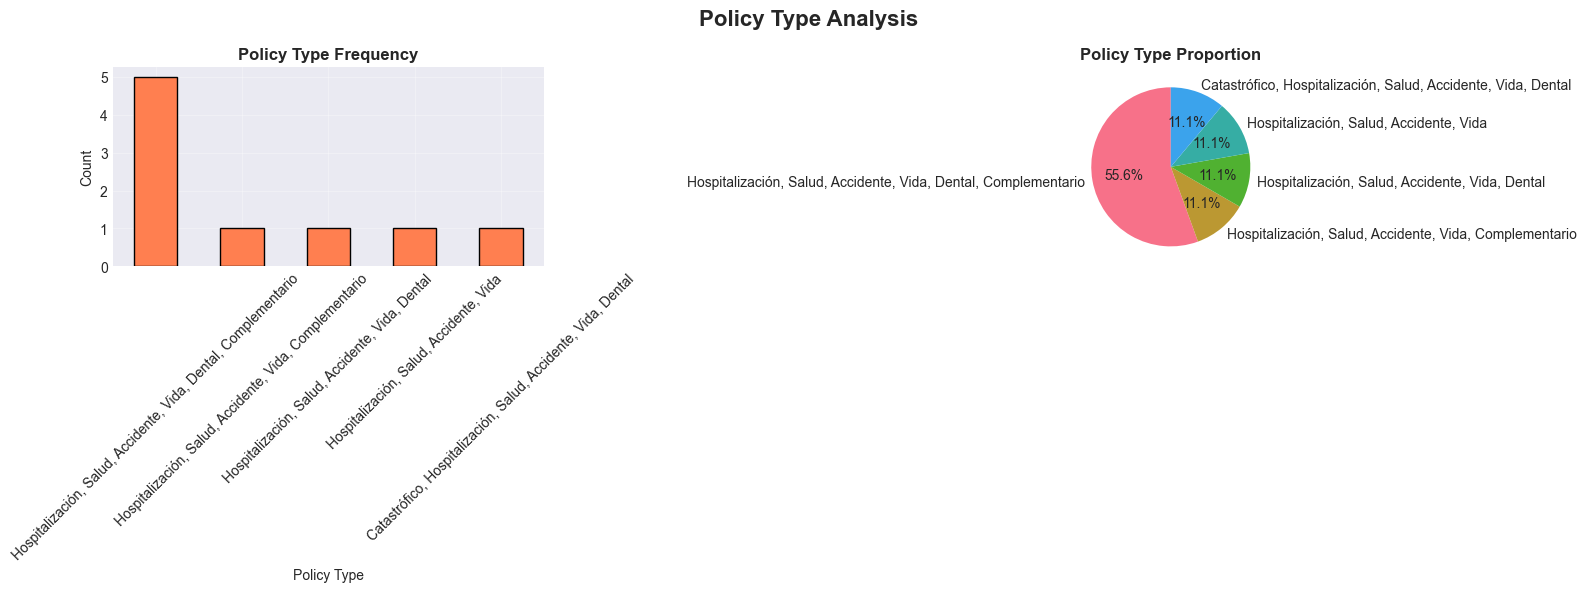

In [9]:
print("Policy Type Distribution:\n")
policy_type_counts = df_clean['policy_type'].value_counts()
print(policy_type_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Policy Type Analysis', fontsize=16, fontweight='bold')

policy_type_counts.plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Policy Type Frequency', fontweight='bold')
ax1.set_xlabel('Policy Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

policy_type_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Policy Type Proportion', fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

In [10]:
coverage_cols = ['cobertura', 'reembolso', 'deducible', 'prima', 
                 'exclusión', 'beneficio', 'asegurado', 'prestación']

print("Coverage Keywords Statistics:\n")
df_clean[coverage_cols].describe().T

Coverage Keywords Statistics:



,count,mean,std,min,25%,50%,75%,max
cobertura,9.0,31.333333,19.241881,12.0,21.0,23.0,37.0,74.0
reembolso,9.0,27.333333,13.964240,2.0,22.0,34.0,36.0,45.0
deducible,9.0,10.666667,6.652067,3.0,5.0,11.0,13.0,25.0
prima,9.0,19.777778,16.513463,2.0,5.0,24.0,25.0,55.0
exclusión,9.0,0.555556,1.333333,0.0,0.0,0.0,0.0,4.0
beneficio,9.0,13.222222,16.521030,0.0,1.0,6.0,18.0,45.0
asegurado,9.0,125.888889,65.164109,8.0,95.0,139.0,165.0,222.0
prestación,9.0,4.666667,3.240370,1.0,2.0,4.0,7.0,10.0


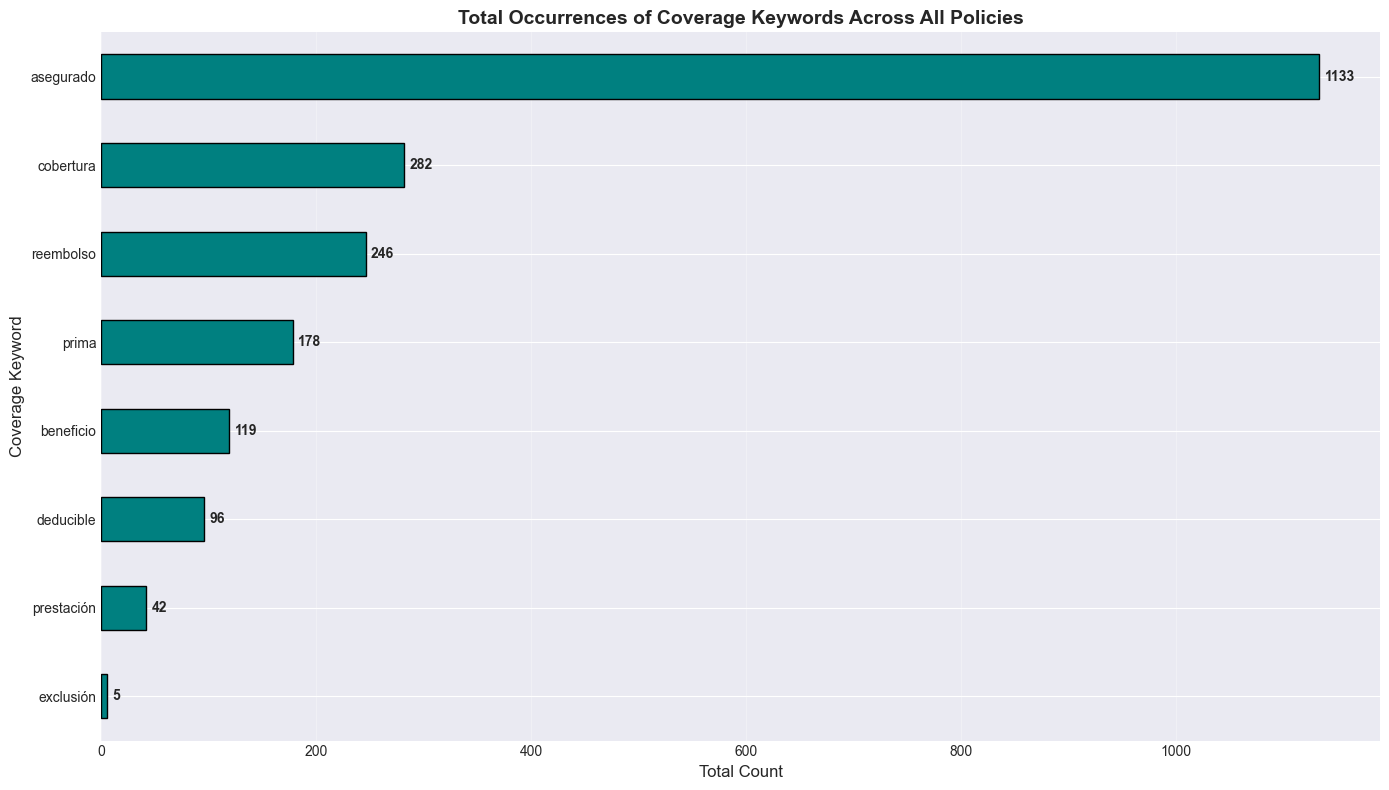

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))

coverage_totals = df_clean[coverage_cols].sum().sort_values(ascending=True)
coverage_totals.plot(kind='barh', ax=ax, color='teal', edgecolor='black')

ax.set_title('Total Occurrences of Coverage Keywords Across All Policies', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Count', fontsize=12)
ax.set_ylabel('Coverage Keyword', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(coverage_totals.values):
    ax.text(v + 5, i, str(int(v)), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Bivariate and Multivariate Analysis

We'll explore relationships between different variables.

Correlation Matrix for Numerical Features:

                    text_length  word_count  article_count  page_count  \
text_length            1.000000    0.999279       0.445885    0.783286   
word_count             0.999279    1.000000       0.476582    0.760897   
article_count          0.445885    0.476582       1.000000   -0.140123   
page_count             0.783286    0.760897      -0.140123    1.000000   
avg_words_per_page    -0.188771   -0.156904       0.621483   -0.704347   
avg_chars_per_word     0.285052    0.254072      -0.574276    0.652007   

                    avg_words_per_page  avg_chars_per_word  
text_length                  -0.188771            0.285052  
word_count                   -0.156904            0.254072  
article_count                 0.621483           -0.574276  
page_count                   -0.704347            0.652007  
avg_words_per_page            1.000000           -0.743610  
avg_chars_per_word           -0.743610            1.000000  


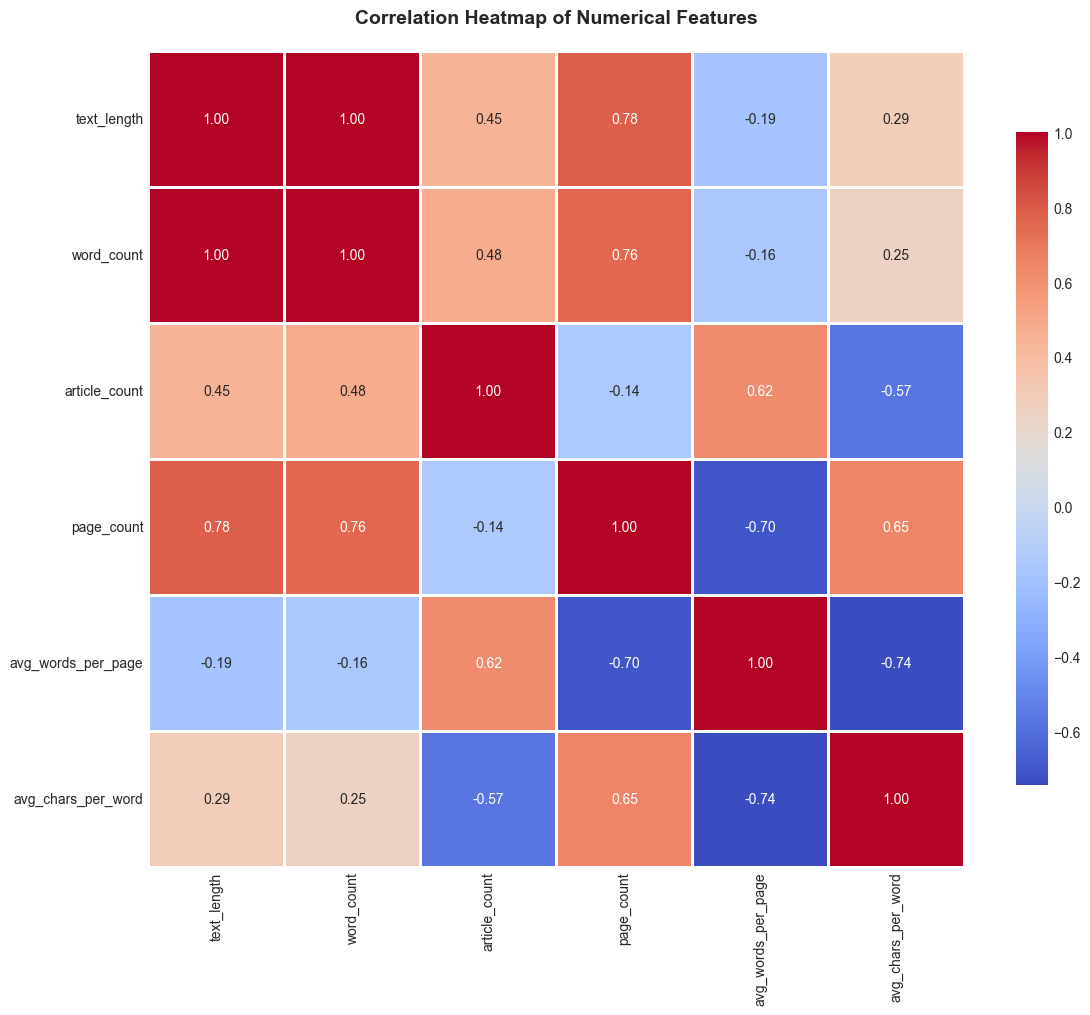

In [12]:
print("Correlation Matrix for Numerical Features:\n")
correlation_matrix = df_clean[numeric_cols].corr()
print(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

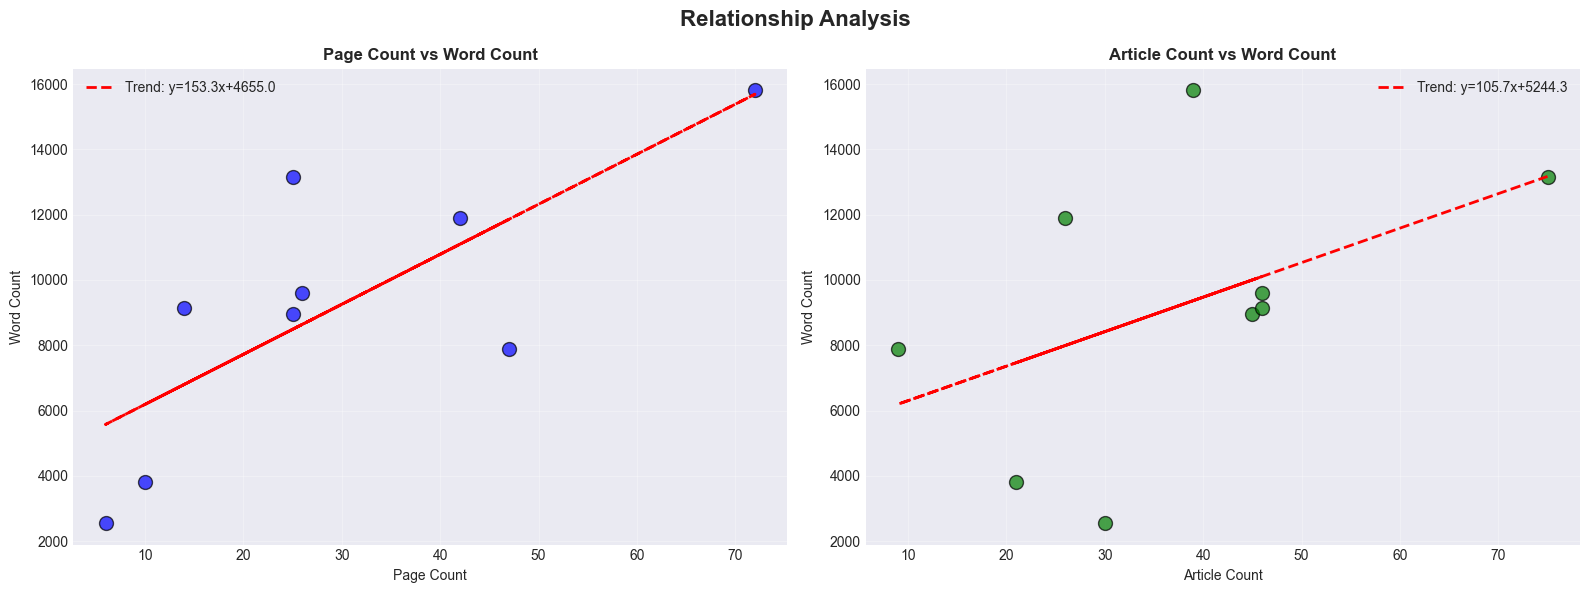

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Relationship Analysis', fontsize=16, fontweight='bold')

axes[0].scatter(df_clean['page_count'], df_clean['word_count'], 
                alpha=0.7, s=100, c='blue', edgecolors='black')
axes[0].set_title('Page Count vs Word Count', fontweight='bold')
axes[0].set_xlabel('Page Count')
axes[0].set_ylabel('Word Count')
axes[0].grid(True, alpha=0.3)

z = np.polyfit(df_clean['page_count'], df_clean['word_count'], 1)
p = np.poly1d(z)
axes[0].plot(df_clean['page_count'], p(df_clean['page_count']), 
             "r--", linewidth=2, label=f'Trend: y={z[0]:.1f}x+{z[1]:.1f}')
axes[0].legend()

axes[1].scatter(df_clean['article_count'], df_clean['word_count'], 
                alpha=0.7, s=100, c='green', edgecolors='black')
axes[1].set_title('Article Count vs Word Count', fontweight='bold')
axes[1].set_xlabel('Article Count')
axes[1].set_ylabel('Word Count')
axes[1].grid(True, alpha=0.3)

z2 = np.polyfit(df_clean['article_count'], df_clean['word_count'], 1)
p2 = np.poly1d(z2)
axes[1].plot(df_clean['article_count'], p2(df_clean['article_count']), 
             "r--", linewidth=2, label=f'Trend: y={z2[0]:.1f}x+{z2[1]:.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
policy_type_simple = df_clean['policy_type'].apply(
    lambda x: x.split(',')[0].strip() if ',' in x else x
)

comparison_df = df_clean.copy()
comparison_df['policy_type_main'] = policy_type_simple

grouped_stats = comparison_df.groupby('policy_type_main').agg({
    'word_count': ['mean', 'median', 'std'],
    'article_count': ['mean', 'median', 'std'],
    'page_count': ['mean', 'median', 'std']
}).round(2)

print("Statistics by Policy Type:\n")
print(grouped_stats)

Statistics by Policy Type:

                 word_count                   article_count               \
                       mean   median      std          mean median   std   
policy_type_main                                                           
Catastrófico       13156.00  13156.0      NaN         75.00   75.0   NaN   
Hospitalización     8708.38   9050.0  4212.62         32.75   34.5  13.6   

                 page_count                
                       mean median    std  
policy_type_main                           
Catastrófico          25.00   25.0    NaN  
Hospitalización       30.25   25.5  22.26  


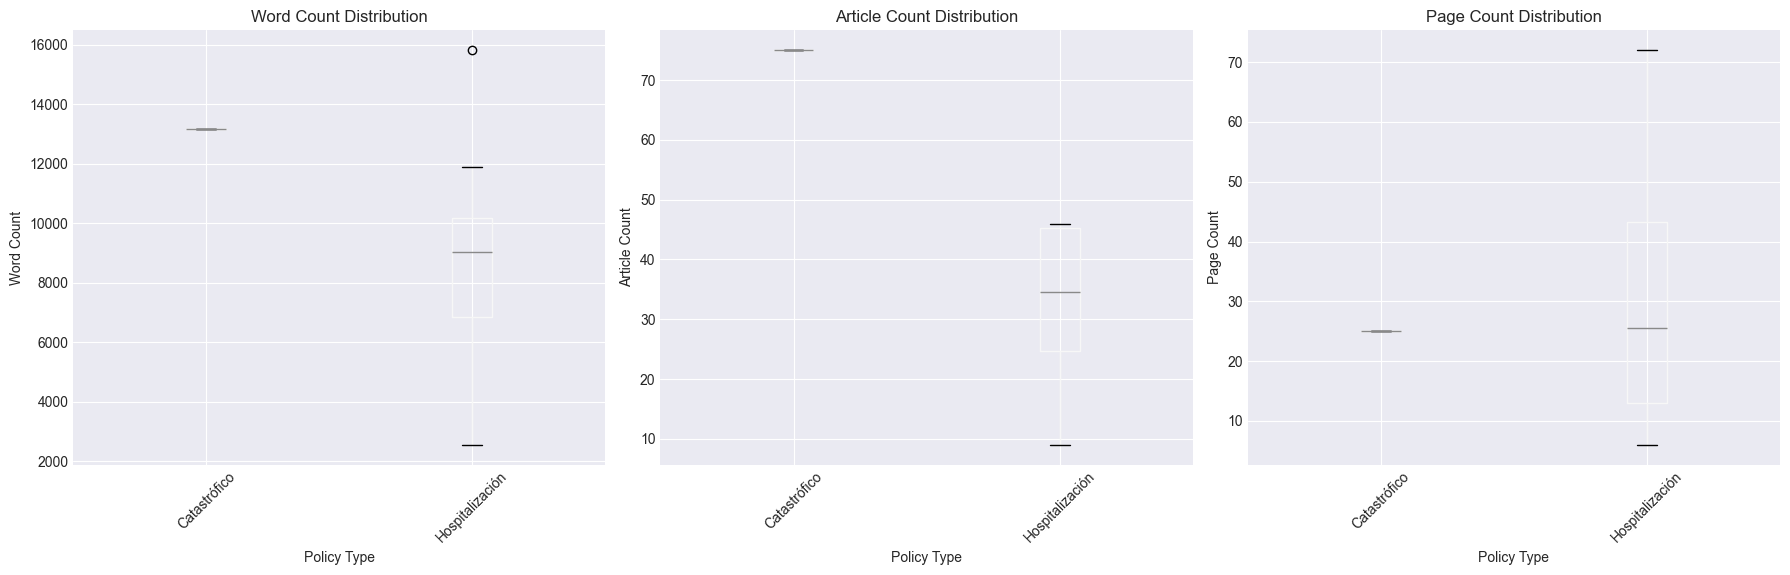

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Policy Characteristics by Type', fontsize=16, fontweight='bold')

comparison_df.boxplot(column='word_count', by='policy_type_main', ax=axes[0])
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Policy Type')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=45)

comparison_df.boxplot(column='article_count', by='policy_type_main', ax=axes[1])
axes[1].set_title('Article Count Distribution')
axes[1].set_xlabel('Policy Type')
axes[1].set_ylabel('Article Count')
axes[1].tick_params(axis='x', rotation=45)

comparison_df.boxplot(column='page_count', by='policy_type_main', ax=axes[2])
axes[2].set_title('Page Count Distribution')
axes[2].set_xlabel('Policy Type')
axes[2].set_ylabel('Page Count')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

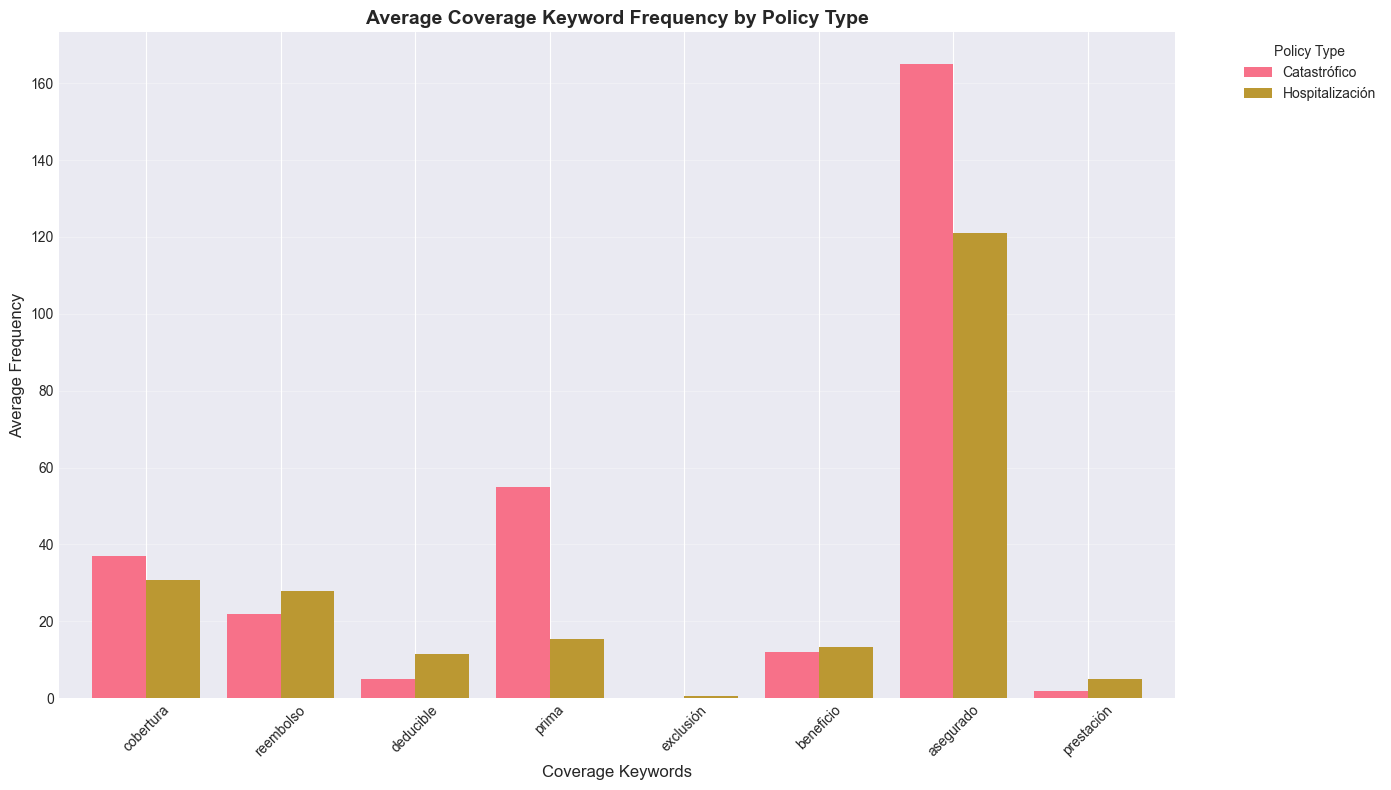

In [16]:
coverage_by_policy = comparison_df.groupby('policy_type_main')[coverage_cols].mean()

plt.figure(figsize=(14, 8))
coverage_by_policy.T.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('Average Coverage Keyword Frequency by Policy Type', fontsize=14, fontweight='bold')
plt.xlabel('Coverage Keywords', fontsize=12)
plt.ylabel('Average Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Policy Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. Additional Visualizations and Insights

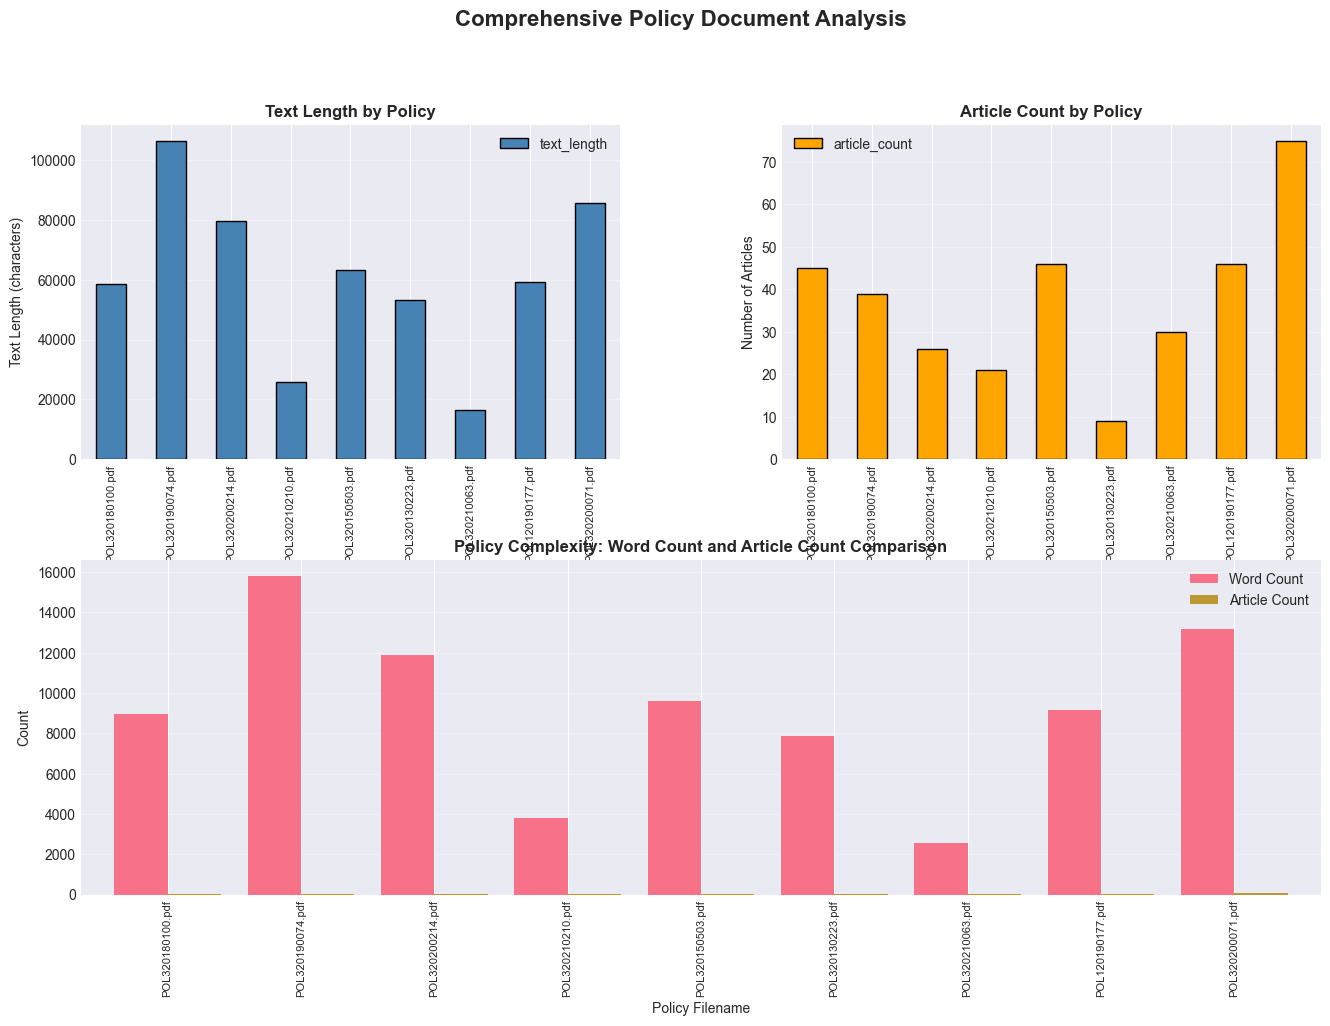

In [17]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
df_clean.plot(x='filename', y='text_length', kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Text Length by Policy', fontweight='bold')
ax1.set_xlabel('Policy Filename')
ax1.set_ylabel('Text Length (characters)')
ax1.tick_params(axis='x', rotation=90, labelsize=8)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = fig.add_subplot(gs[0, 1])
df_clean.plot(x='filename', y='article_count', kind='bar', ax=ax2, color='orange', edgecolor='black')
ax2.set_title('Article Count by Policy', fontweight='bold')
ax2.set_xlabel('Policy Filename')
ax2.set_ylabel('Number of Articles')
ax2.tick_params(axis='x', rotation=90, labelsize=8)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(gs[1, :])
policy_complexity = df_clean[['filename', 'word_count', 'article_count']].set_index('filename')
policy_complexity.plot(kind='bar', ax=ax3, width=0.8)
ax3.set_title('Policy Complexity: Word Count and Article Count Comparison', fontweight='bold')
ax3.set_xlabel('Policy Filename')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=90, labelsize=8)
ax3.legend(['Word Count', 'Article Count'])
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comprehensive Policy Document Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

Policy Complexity Scores:

           filename                                        policy_type  \
1  POL320190074.pdf  Hospitalización, Salud, Accidente, Vida, Denta...   
8  POL320200071.pdf  Catastrófico, Hospitalización, Salud, Accident...   
2  POL320200214.pdf  Hospitalización, Salud, Accidente, Vida, Compl...   
4  POL320150503.pdf  Hospitalización, Salud, Accidente, Vida, Denta...   
0  POL320180100.pdf  Hospitalización, Salud, Accidente, Vida, Denta...   
7  POL120190177.pdf  Hospitalización, Salud, Accidente, Vida, Denta...   
5  POL320130223.pdf  Hospitalización, Salud, Accidente, Vida, Denta...   
3  POL320210210.pdf    Hospitalización, Salud, Accidente, Vida, Dental   
6  POL320210063.pdf            Hospitalización, Salud, Accidente, Vida   

   complexity_score  
1         85.600000  
8         73.695614  
2         58.009404  
4         53.524739  
0         51.073974  
7         47.361140  
5         43.108711  
3         22.219484  
6         20.963037  


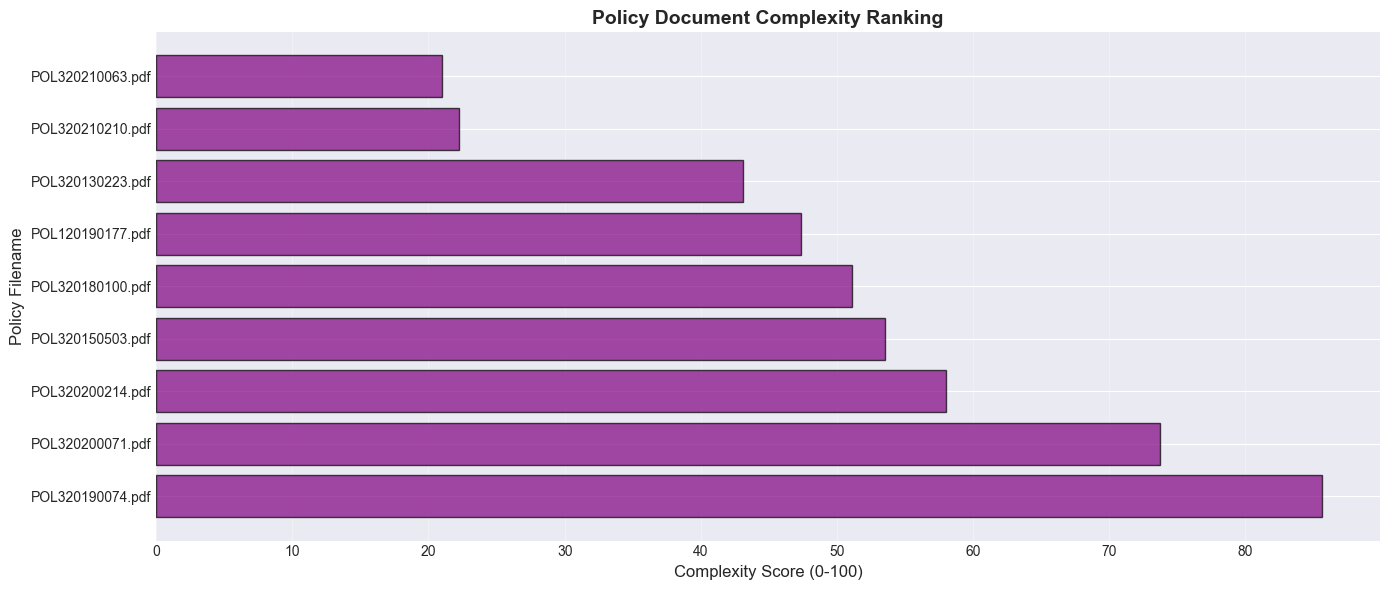

In [18]:
df_clean['complexity_score'] = (
    (df_clean['word_count'] / df_clean['word_count'].max()) * 0.4 +
    (df_clean['article_count'] / df_clean['article_count'].max()) * 0.3 +
    (df_clean['page_count'] / df_clean['page_count'].max()) * 0.3
) * 100

print("Policy Complexity Scores:\n")
complexity_ranking = df_clean[['filename', 'policy_type', 'complexity_score']].sort_values(
    'complexity_score', ascending=False
)
print(complexity_ranking)

plt.figure(figsize=(14, 6))
plt.barh(complexity_ranking['filename'], complexity_ranking['complexity_score'], 
         color='purple', edgecolor='black', alpha=0.7)
plt.title('Policy Document Complexity Ranking', fontsize=14, fontweight='bold')
plt.xlabel('Complexity Score (0-100)', fontsize=12)
plt.ylabel('Policy Filename', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Testable Data-Driven Questions

This section contains complex questions that can be answered directly using the extracted data, along with Python code to calculate the answers.

### Question 1: What is the average number of articles per policy for each policy type?

Answer to Question 1:
Average number of articles per policy type:

                  Average Articles  Median Articles  Std Dev  \
policy_type_main                                               
Catastrófico                 75.00             75.0      NaN   
Hospitalización              32.75             34.5     13.6   

                  Number of Policies  
policy_type_main                      
Catastrófico                       1  
Hospitalización                    8  


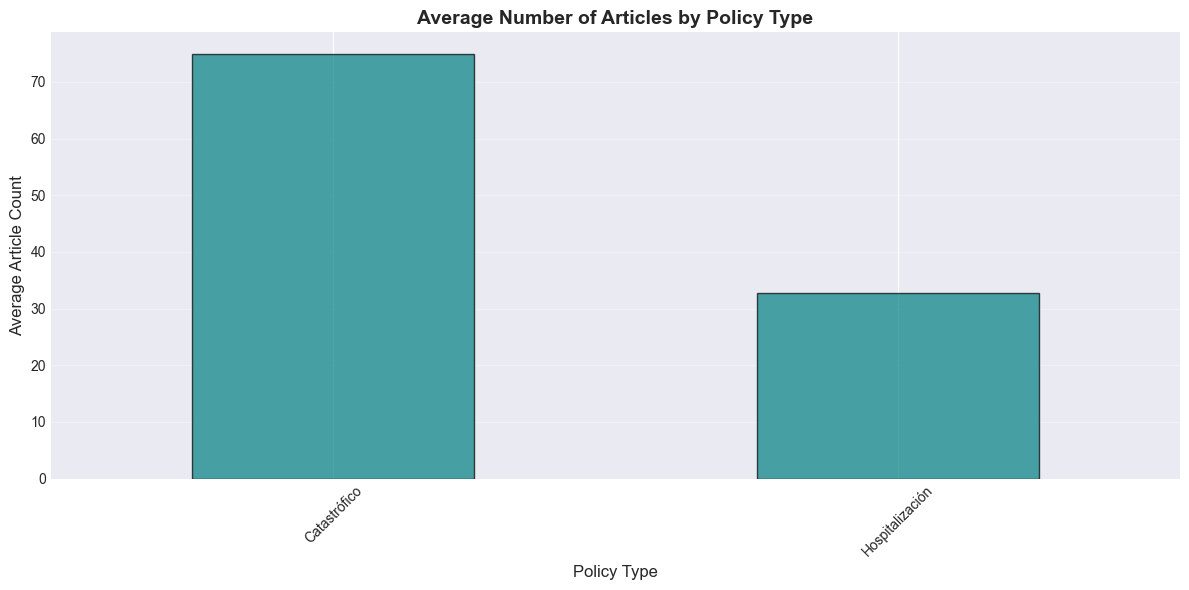


Key Insight: The policy type with the most articles on average is 'Catastrófico' with 75.00 articles.


In [19]:
q1_result = comparison_df.groupby('policy_type_main')['article_count'].agg(['mean', 'median', 'std', 'count'])
q1_result.columns = ['Average Articles', 'Median Articles', 'Std Dev', 'Number of Policies']
q1_result = q1_result.round(2)

print("Answer to Question 1:")
print("Average number of articles per policy type:\n")
print(q1_result)

plt.figure(figsize=(12, 6))
q1_result['Average Articles'].plot(kind='bar', color='teal', edgecolor='black', alpha=0.7)
plt.title('Average Number of Articles by Policy Type', fontsize=14, fontweight='bold')
plt.xlabel('Policy Type', fontsize=12)
plt.ylabel('Average Article Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nKey Insight: The policy type with the most articles on average is '{q1_result['Average Articles'].idxmax()}' "
      f"with {q1_result['Average Articles'].max():.2f} articles.")

### Question 2: What is the relationship between document length (word count) and the frequency of coverage-related terms (e.g., 'cobertura', 'reembolso')?

Answer to Question 2:

Correlation between word count and coverage terms:

                      word_count  total_coverage_terms  coverage_density
word_count              1.000000              0.983948          0.584860
total_coverage_terms    0.983948              1.000000          0.690097
coverage_density        0.584860              0.690097          1.000000


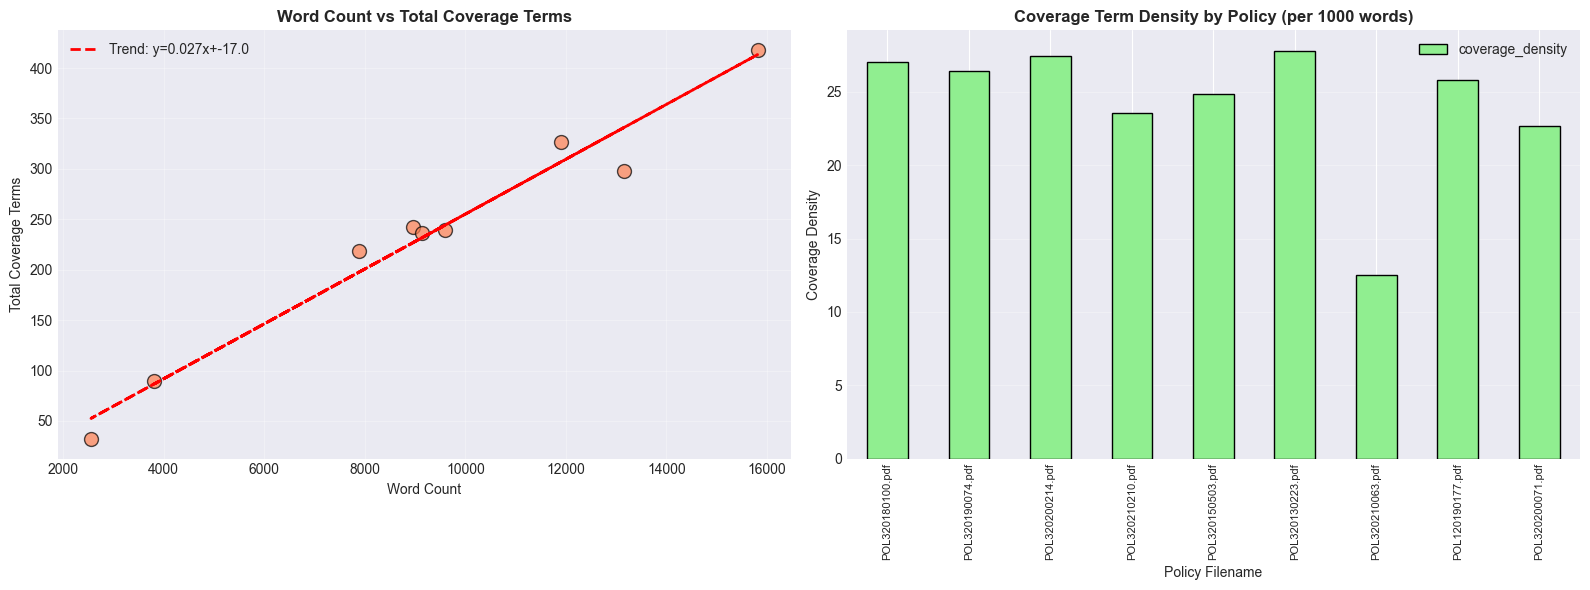


Key Insight: There is a correlation of 0.984 between word count and total coverage terms.


In [20]:
df_clean['total_coverage_terms'] = df_clean[coverage_cols].sum(axis=1)
df_clean['coverage_density'] = (df_clean['total_coverage_terms'] / df_clean['word_count']) * 1000

correlation_cov_words = df_clean[['word_count', 'total_coverage_terms', 'coverage_density']].corr()

print("Answer to Question 2:")
print("\nCorrelation between word count and coverage terms:\n")
print(correlation_cov_words)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_clean['word_count'], df_clean['total_coverage_terms'], 
                s=100, alpha=0.7, c='coral', edgecolors='black')
axes[0].set_title('Word Count vs Total Coverage Terms', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Total Coverage Terms')
axes[0].grid(True, alpha=0.3)

z = np.polyfit(df_clean['word_count'], df_clean['total_coverage_terms'], 1)
p = np.poly1d(z)
axes[0].plot(df_clean['word_count'], p(df_clean['word_count']), 
             "r--", linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.1f}')
axes[0].legend()

df_clean.plot(x='filename', y='coverage_density', kind='bar', ax=axes[1], 
              color='lightgreen', edgecolor='black')
axes[1].set_title('Coverage Term Density by Policy (per 1000 words)', fontweight='bold')
axes[1].set_xlabel('Policy Filename')
axes[1].set_ylabel('Coverage Density')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nKey Insight: There is a correlation of {correlation_cov_words.loc['word_count', 'total_coverage_terms']:.3f} "
      f"between word count and total coverage terms.")

### Question 3: Which policies mention 'deducible' (deductible) more frequently than 'reembolso' (reimbursement), and what is the ratio?

Answer to Question 3:

Number of policies with more 'deducible' mentions than 'reembolso': 1
Out of 9 total policies.

Policies with more 'deducible' than 'reembolso':

           filename                              policy_type  deducible  \
6  POL320210063.pdf  Hospitalización, Salud, Accidente, Vida          5   

   reembolso  deducible_to_reembolso_ratio  
6          2                      1.666667  


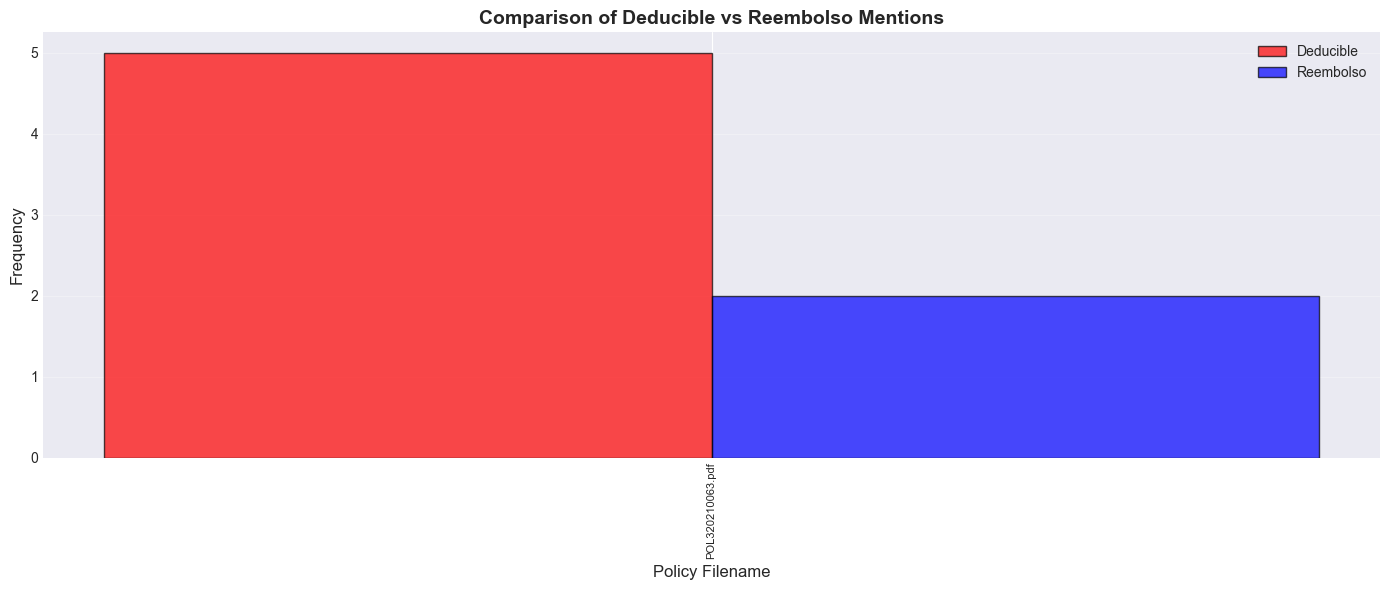


Average ratio across all policies: 0.516


In [21]:
df_clean['deducible_to_reembolso_ratio'] = df_clean['deducible'] / (df_clean['reembolso'] + 1)

policies_more_deducible = df_clean[df_clean['deducible'] > df_clean['reembolso']]

print("Answer to Question 3:")
print(f"\nNumber of policies with more 'deducible' mentions than 'reembolso': {len(policies_more_deducible)}")
print(f"Out of {len(df_clean)} total policies.\n")

if len(policies_more_deducible) > 0:
    print("Policies with more 'deducible' than 'reembolso':\n")
    result_table = policies_more_deducible[[
        'filename', 'policy_type', 'deducible', 'reembolso', 'deducible_to_reembolso_ratio'
    ]].sort_values('deducible_to_reembolso_ratio', ascending=False)
    print(result_table)
    
    plt.figure(figsize=(14, 6))
    x = np.arange(len(result_table))
    width = 0.35
    
    plt.bar(x - width/2, result_table['deducible'], width, label='Deducible', 
            color='red', alpha=0.7, edgecolor='black')
    plt.bar(x + width/2, result_table['reembolso'], width, label='Reembolso', 
            color='blue', alpha=0.7, edgecolor='black')
    
    plt.xlabel('Policy Filename', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Comparison of Deducible vs Reembolso Mentions', fontsize=14, fontweight='bold')
    plt.xticks(x, result_table['filename'], rotation=90, fontsize=8)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("No policies found with more 'deducible' mentions than 'reembolso'.")

print(f"\nAverage ratio across all policies: {df_clean['deducible_to_reembolso_ratio'].mean():.3f}")

### Question 4: What is the distribution of exclusion mentions ('exclusión') across different policy types, and which type has the highest average?

Answer to Question 4:

Exclusion mentions by policy type:

                  Total Exclusions  Average Exclusions  Median Exclusions  \
policy_type_main                                                            
Hospitalización                  5                0.62                0.0   
Catastrófico                     0                0.00                0.0   

                  Max Exclusions  Policy Count  
policy_type_main                                
Hospitalización                4             8  
Catastrófico                   0             1  


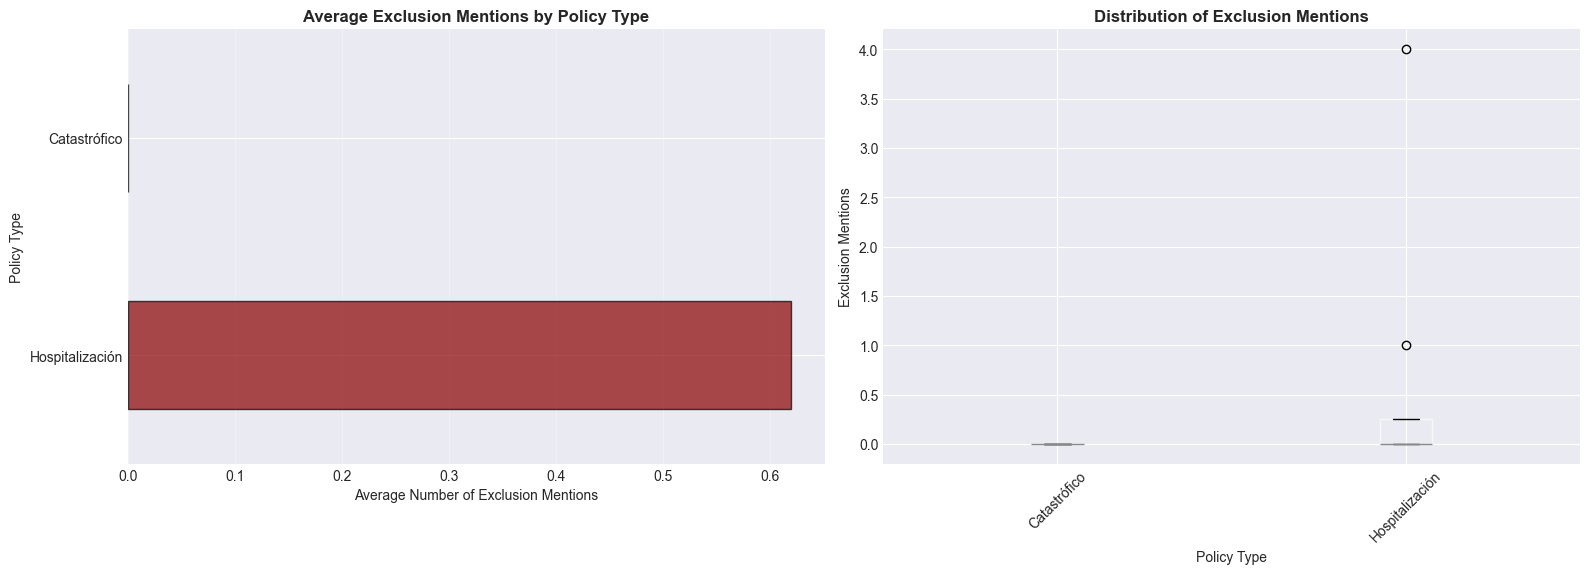


Key Insight: The policy type 'Hospitalización' has the highest average exclusion mentions with 0.62 mentions per policy.


In [22]:
exclusion_by_type = comparison_df.groupby('policy_type_main')['exclusión'].agg([
    ('Total Exclusions', 'sum'),
    ('Average Exclusions', 'mean'),
    ('Median Exclusions', 'median'),
    ('Max Exclusions', 'max'),
    ('Policy Count', 'count')
]).round(2)

exclusion_by_type = exclusion_by_type.sort_values('Average Exclusions', ascending=False)

print("Answer to Question 4:")
print("\nExclusion mentions by policy type:\n")
print(exclusion_by_type)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

exclusion_by_type['Average Exclusions'].plot(kind='barh', ax=axes[0], 
                                               color='darkred', edgecolor='black', alpha=0.7)
axes[0].set_title('Average Exclusion Mentions by Policy Type', fontweight='bold')
axes[0].set_xlabel('Average Number of Exclusion Mentions')
axes[0].set_ylabel('Policy Type')
axes[0].grid(True, alpha=0.3, axis='x')

comparison_df.boxplot(column='exclusión', by='policy_type_main', ax=axes[1])
axes[1].set_title('Distribution of Exclusion Mentions', fontweight='bold')
axes[1].set_xlabel('Policy Type')
axes[1].set_ylabel('Exclusion Mentions')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

highest_exclusion_type = exclusion_by_type['Average Exclusions'].idxmax()
highest_exclusion_value = exclusion_by_type['Average Exclusions'].max()

print(f"\nKey Insight: The policy type '{highest_exclusion_type}' has the highest average exclusion mentions "
      f"with {highest_exclusion_value:.2f} mentions per policy.")

### Question 5: Is there a correlation between policy complexity (as measured by article count and page count) and the frequency of legal/administrative terms ('asegurado', 'prima', 'beneficio')?

Answer to Question 5:

Correlation matrix between complexity and legal terms:

                   article_count  page_count  complexity_metric  asegurado  \
article_count              1.000      -0.140              0.538      0.432   
page_count                -0.140       1.000              0.721      0.730   
complexity_metric          0.538       0.721              1.000      0.868   
asegurado                  0.432       0.730              0.868      1.000   
prima                      0.859      -0.045              0.444      0.540   
beneficio                 -0.301       0.918              0.543      0.491   
legal_terms_total          0.450       0.746              0.877      0.990   

                   prima  beneficio  legal_terms_total  
article_count      0.859     -0.301              0.450  
page_count        -0.045      0.918              0.746  
complexity_metric  0.444      0.543              0.877  
asegurado          0.540      0.491              0.990  
prima      

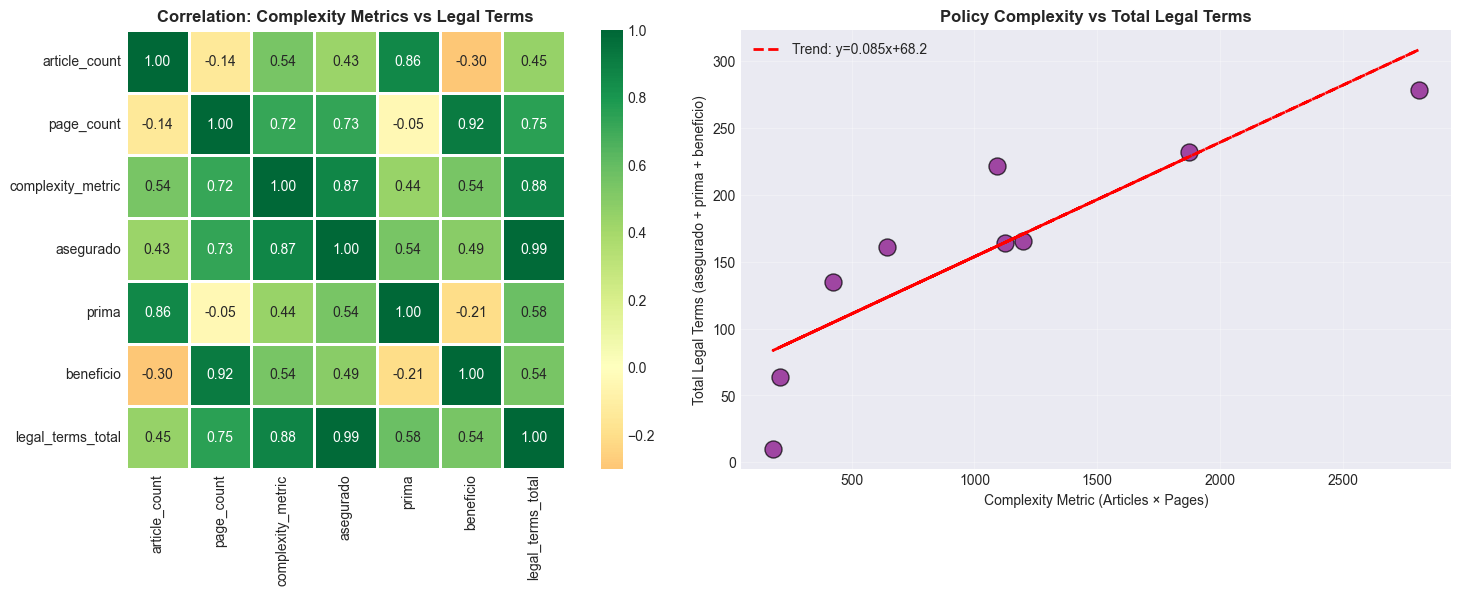


Key Insight: The correlation between policy complexity and legal term frequency is 0.877.
This indicates a strong positive relationship.


In [23]:
df_clean['legal_terms_total'] = df_clean['asegurado'] + df_clean['prima'] + df_clean['beneficio']
df_clean['complexity_metric'] = df_clean['article_count'] * df_clean['page_count']

correlation_complexity_legal = df_clean[[
    'article_count', 'page_count', 'complexity_metric', 
    'asegurado', 'prima', 'beneficio', 'legal_terms_total'
]].corr()

print("Answer to Question 5:")
print("\nCorrelation matrix between complexity and legal terms:\n")
print(correlation_complexity_legal.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(correlation_complexity_legal, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, ax=axes[0], square=True, linewidths=1)
axes[0].set_title('Correlation: Complexity Metrics vs Legal Terms', fontweight='bold')

axes[1].scatter(df_clean['complexity_metric'], df_clean['legal_terms_total'], 
                s=150, alpha=0.7, c='purple', edgecolors='black')
axes[1].set_title('Policy Complexity vs Total Legal Terms', fontweight='bold')
axes[1].set_xlabel('Complexity Metric (Articles × Pages)')
axes[1].set_ylabel('Total Legal Terms (asegurado + prima + beneficio)')
axes[1].grid(True, alpha=0.3)

z = np.polyfit(df_clean['complexity_metric'], df_clean['legal_terms_total'], 1)
p = np.poly1d(z)
axes[1].plot(df_clean['complexity_metric'], p(df_clean['complexity_metric']), 
             "r--", linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

corr_value = correlation_complexity_legal.loc['complexity_metric', 'legal_terms_total']
print(f"\nKey Insight: The correlation between policy complexity and legal term frequency is {corr_value:.3f}.")
if corr_value > 0.7:
    print("This indicates a strong positive relationship.")
elif corr_value > 0.3:
    print("This indicates a moderate positive relationship.")
else:
    print("This indicates a weak relationship.")

## 8. Summary and Conclusions

In [24]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)
print(f"\nTotal Policies Analyzed: {len(df_clean)}")
print(f"\nPolicy Types Identified: {df_clean['policy_type'].nunique()}")
print(f"\nKey Statistics:")
print(f"  - Average Word Count: {df_clean['word_count'].mean():.0f} words")
print(f"  - Average Article Count: {df_clean['article_count'].mean():.1f} articles")
print(f"  - Average Page Count: {df_clean['page_count'].mean():.1f} pages")
print(f"  - Total Coverage Terms Across All Policies: {df_clean['total_coverage_terms'].sum():.0f}")

print(f"\nMost Complex Policy: {complexity_ranking.iloc[0]['filename']}")
print(f"  - Complexity Score: {complexity_ranking.iloc[0]['complexity_score']:.2f}/100")

print(f"\nLeast Complex Policy: {complexity_ranking.iloc[-1]['filename']}")
print(f"  - Complexity Score: {complexity_ranking.iloc[-1]['complexity_score']:.2f}/100")

print(f"\nMost Common Coverage Keyword: '{coverage_totals.idxmax()}' ({int(coverage_totals.max())} occurrences)")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)

EXPLORATORY DATA ANALYSIS SUMMARY

Total Policies Analyzed: 9

Policy Types Identified: 5

Key Statistics:
  - Average Word Count: 9203 words
  - Average Article Count: 37.4 articles
  - Average Page Count: 29.7 pages
  - Total Coverage Terms Across All Policies: 2101

Most Complex Policy: POL320190074.pdf
  - Complexity Score: 85.60/100

Least Complex Policy: POL320210063.pdf
  - Complexity Score: 20.96/100

Most Common Coverage Keyword: 'asegurado' (1133 occurrences)

END OF ANALYSIS


In [25]:
output_csv = 'data/structure_data/eda_extracted_data.csv'
df_clean_export = df_clean.drop('full_text', axis=1)
df_clean_export.to_csv(output_csv, index=False, encoding='utf-8')
print(f"Cleaned and processed data exported to: {output_csv}")

Cleaned and processed data exported to: data/structure_data/eda_extracted_data.csv
